**IMPORTING & ENVIRONMENT SETUP**

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files
import os

# quick helper for the hex codes
def get_hex(rgb_val):
    return '#%02x%02x%02x' % tuple(rgb_val)

print("Environment Setup Is Complete!!!!.")

Environment Setup Is Complete!!!!.


In [12]:
# Batch upload photos (you can select multiple at once)
print("Select your screenshots or figure photos:")
uploaded_files = files.upload()
file_list = list(uploaded_files.keys())

print(f"\nUploaded: {file_list}")

# User chooses which one to run
while True:
    target = input("\nWhich image should we analyze? (or type 'exit'): ").strip()
    if target.lower() == 'exit':
        break
    if target in file_list:
        print(f"Working on {target}...")
        break
    else:
        print(f"Wait, '{target}' isn't in the list. Check the spelling.")

Select your screenshots or figure photos:


Saving Sukuna.jpg to Sukuna.jpg
Saving TheBatman.jpg to TheBatman.jpg

Uploaded: ['Sukuna.jpg', 'TheBatman.jpg']

Which image should we analyze? (or type 'exit'): Sukuna.jpg
Working on Sukuna.jpg...


In [14]:
def extract_cinematic_palette(img_path, clusters=5):
    # load and fix color space
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # downsample for speed (big data best practice)
    # we call it 'thumb' for thumbnail
    thumb = cv2.resize(raw_img, (150, 150), interpolation=cv2.INTER_AREA)
    data = thumb.reshape((-1, 3))

    # fit the clusters
    engine = KMeans(n_clusters=clusters, n_init="auto", random_state=1)
    engine.fit(data)

    # grab colors and sort them by 'luma' (brightness)
    # so the palette looks professional
    found_colors = engine.cluster_centers_.astype(int)
    found_colors = sorted(found_colors, key=lambda c: (0.2126*c[0] + 0.7152*c[1] + 0.0722*c[2]), reverse=True)

    return raw_img, found_colors

# Run the function
main_img, palette_colors = extract_cinematic_palette(target, clusters=6)

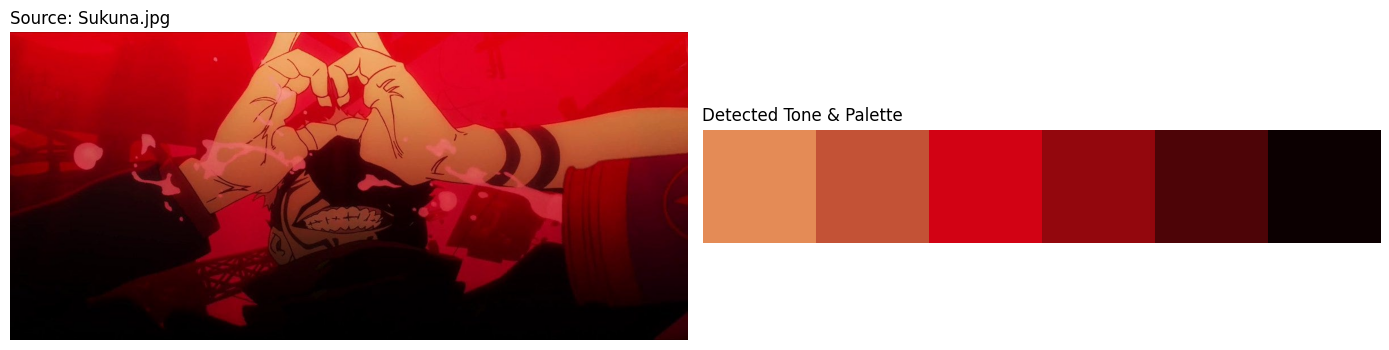


Generated Hex Codes for Sukuna.jpg:
#E48B56 | #C35236 | #D20214 | #93070D | #4D0407 | #0C0001


In [15]:
# building the visual strip
strip = np.zeros((100, 600, 3), dtype=np.uint8)
w = 600 // len(palette_colors)

for i, c in enumerate(palette_colors):
    strip[:, i*w:(i+1)*w] = c

# Final Display
plt.figure(figsize=(14, 7))

# The photo
plt.subplot(1, 2, 1)
plt.imshow(main_img)
plt.title(f"Source: {target}", fontsize=12, loc='left')
plt.axis('off')

# The palette
plt.subplot(1, 2, 2)
plt.imshow(strip)
plt.title("Detected Tone & Palette", fontsize=12, loc='left')
plt.axis('off')

plt.tight_layout()
plt.show()

# Clean output for the hex codes
hex_list = [get_hex(c) for c in palette_colors]
print(f"\nGenerated Hex Codes for {target}:")
print(" | ".join(hex_list).upper())